In [1]:
import os
import joblib
import optuna
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

/home/aliarridha/miniconda3/envs/modeling1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
BASE_PATH = 'dataset'
MODELS = os.path.join(BASE_PATH, 'models')
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
DATASET = os.path.join(BASE_PATH, 'dataset_produksi_padi.csv')

os.makedirs(os.path.join(OUTPUT_PIPELINE, 'random_forest'), exist_ok=True)

In [5]:
df = pd.read_csv(DATASET)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2529 entries, 0 to 2528
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           2529 non-null   object 
 1   luas_panen          2529 non-null   float64
 2   produktivitas       2529 non-null   float64
 3   produksi            2529 non-null   float64
 4   tahun               2529 non-null   int64  
 5   curah_hujan_rataan  2529 non-null   float64
 6   curah_hujan_total   2529 non-null   float64
 7   suhu_rataan         2529 non-null   float64
 8   suhu_maksimum       2529 non-null   float64
 9   suhu_minimum        2529 non-null   float64
 10  kelembapan_rataan   2529 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 217.5+ KB


In [7]:
X_train = df.drop(columns=['kabupaten', 'produksi', 'produktivitas'])
y_train = df['produksi']

X_arr = X_train.to_numpy()
y_arr = y_train.to_numpy()

In [8]:
# Menghitung total seluruh data
total_baris = X_arr.shape[0]

print(f"=== RINGKASAN DATASET ===")
print(f"Total Keseluruhan Data: {total_baris} baris\n")
kf_check = KFold(n_splits=5, shuffle=True, random_state=42)

# Mengambil ukuran pembagian di dalam K-Fold pertama
for fold, (train_idx, val_idx) in enumerate(kf_check.split(X_arr), 1):
    jumlah_train = len(train_idx)
    jumlah_val = len(val_idx)
    
    print(f"Fold {fold}:")
    print(f"Jumlah Data Train: {jumlah_train} baris ({jumlah_train/total_baris*100:.1f}%)")
    print(f"Jumlah Data Validasi: {jumlah_val} baris ({jumlah_val/total_baris*100:.1f}%)")
    print(f"Jumlah Data Test: {jumlah_val} baris")
    break

=== RINGKASAN DATASET ===
Total Keseluruhan Data: 2529 baris

Fold 1:
Jumlah Data Train: 2023 baris (80.0%)
Jumlah Data Validasi: 506 baris (20.0%)
Jumlah Data Test: 506 baris


In [9]:
print("Mulai tuning Random Forest (Bayesian - Optuna)")

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 5, 30, step=5),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    fold_mae_scores = []
    
    for train_idx, val_idx in kf.split(X_arr):
        X_train_f, X_val_f = X_arr[train_idx], X_arr[val_idx]
        y_train_f, y_val_f = y_arr[train_idx], y_arr[val_idx]
        
        X_train_scaled = scaler.fit_transform(X_train_f)
        X_val_scaled = scaler.transform(X_val_f)
        
        # Menggunakan RandomForestRegressor
        model = RandomForestRegressor(**params, n_jobs=-1)
        model.fit(X_train_scaled, y_train_f)
        
        val_pred = model.predict(X_val_scaled)
        fold_mae_scores.append(mean_absolute_error(y_val_f, val_pred))
        
    return np.mean(fold_mae_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_mae = study.best_value

print(best_params)
print(f"Rata-rata MAE Terendah saat Tuning: {best_mae:.2f}\n")

Mulai tuning Random Forest (Bayesian - Optuna)


Best trial: 43. Best value: 13248.9: 100%|██████████| 50/50 [01:47<00:00,  2.14s/it]

{'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}
Rata-rata MAE Terendah saat Tuning: 13248.87



In [10]:
def hitung_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [11]:
kf_final = KFold(n_splits=5, shuffle=True, random_state=42)
scaler_final = StandardScaler()
rf_model = RandomForestRegressor(**best_params, n_jobs=-1)

fold_train_mae, fold_train_rmse, fold_train_r2 = [], [], []
fold_val_mae, fold_val_rmse, fold_val_r2 = [], [], []
y_aktual_total = []
y_prediksi_total = []

for fold, (train_idx, val_idx) in enumerate(kf_final.split(X_arr), 1):
    X_train_f, X_val_f = X_arr[train_idx], X_arr[val_idx]
    y_train_f, y_val_f = y_arr[train_idx], y_arr[val_idx]
    
    X_train_scaled = scaler_final.fit_transform(X_train_f)
    X_val_scaled = scaler_final.transform(X_val_f)
    
    rf_model.fit(X_train_scaled, y_train_f)
    
    train_pred_f = rf_model.predict(X_train_scaled)
    val_pred_f = rf_model.predict(X_val_scaled)
    
    y_aktual_total.extend(y_val_f)
    y_prediksi_total.extend(val_pred_f)
    
    t_mae, t_rmse, t_r2 = hitung_metrics(y_train_f, train_pred_f)
    v_mae, v_rmse, v_r2 = hitung_metrics(y_val_f, val_pred_f)
    
    fold_train_mae.append(t_mae)
    fold_train_rmse.append(t_rmse)
    fold_train_r2.append(t_r2)
    
    fold_val_mae.append(v_mae)
    fold_val_rmse.append(v_rmse)
    fold_val_r2.append(v_r2)
    
    print(f"Fold {fold} -> Train R2: {t_r2:.4f} | Val R2: {v_r2:.4f}")

Fold 1 -> Train R2: 0.9978 | Val R2: 0.9864
Fold 2 -> Train R2: 0.9978 | Val R2: 0.9836
Fold 3 -> Train R2: 0.9975 | Val R2: 0.9876
Fold 4 -> Train R2: 0.9977 | Val R2: 0.9824
Fold 5 -> Train R2: 0.9979 | Val R2: 0.9798


In [12]:
print("=== PERFORMA RANDOM FOREST (TUNED) ===")
print("Rata-rata Train ")
print(f"MAE  : {np.mean(fold_train_mae):.4f}")
print(f"RMSE : {np.mean(fold_train_rmse):.4f}")
print(f"R2   : {np.mean(fold_train_r2):.4f} (±{np.std(fold_train_r2):.4f})")

print("\nRata-rata Validation / Cross-Validation")
print(f"MAE  : {np.mean(fold_val_mae):.4f}")
print(f"RMSE : {np.mean(fold_val_rmse):.4f}")
print(f"R2   : {np.mean(fold_val_r2):.4f} (±{np.std(fold_val_r2):.4f})")

=== PERFORMA RANDOM FOREST (TUNED) ===
Rata-rata Train 
MAE  : 4937.1093
RMSE : 10332.6167
R2   : 0.9977 (±0.0001)

Rata-rata Validation / Cross-Validation
MAE  : 13242.5828
RMSE : 27241.7222
R2   : 0.9840 (±0.0028)


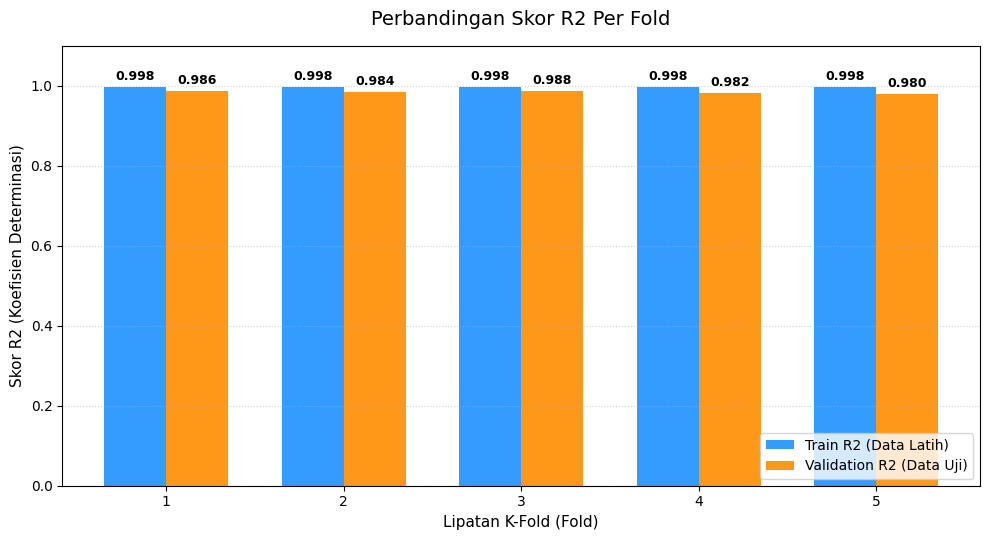

In [13]:
folds = np.arange(1, 6)
width = 0.35            

plt.figure(figsize=(10, 5.5))

plt.bar(folds - width/2, fold_train_r2, width, label='Train R2 (Data Latih)', color='dodgerblue', alpha=0.9)
plt.bar(folds + width/2, fold_val_r2, width, label='Validation R2 (Data Uji)', color='darkorange', alpha=0.9)

for i in range(len(folds)):
    plt.text(
        folds[i] - width/2, 
        fold_train_r2[i] + 0.01, 
        f"{fold_train_r2[i]:.3f}", 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )
    plt.text(
        folds[i] + width/2, 
        fold_val_r2[i] + 0.01, 
        f"{fold_val_r2[i]:.3f}", 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )

# Atribut Grafik
plt.title('Perbandingan Skor R2 Per Fold', fontsize=14, pad=15)
plt.xlabel('Lipatan K-Fold (Fold)', fontsize=11)
plt.ylabel('Skor R2 (Koefisien Determinasi)', fontsize=11)
plt.xticks(folds)
plt.ylim(0, 1.1) # Batas atas ditinggikan sedikit agar teks legenda aman
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE, 'random_forest/r2_comparison_per_fold.png'), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# Simpan Model Random Forest
joblib.dump(
    rf_model,
    os.path.join(MODELS, 'random_forest.joblib')
)
print("Model berhasil disimpan.")

Model berhasil disimpan.


In [ ]:
# Simpan metrics
metrics_rf = pd.DataFrame({
    "model": ["Random Forest"],
    "train_mae": [fold_train_mae],
    "train_rmse": [fold_train_rmse],
    "train_r2": [fold_train_r2],
    "val_mae": [fold_val_mae],
    "val_rmse": [fold_val_rmse],
    "val_r2": [fold_val_r2],
})

metrics_rf.to_csv(
    os.path.join(OUTPUT_PIPELINE, "random_forest/random_forest_metrics.csv"),
    index=False
)
print("Metrics berhasil disimpan.")

Metrics berhasil disimpan.


In [16]:
# Simpan hasil prediksi test
y_aktual_total.extend(y_val_f)
y_prediksi_total.extend(val_pred_f)

df_hasil = pd.DataFrame({
    'Nilai Aktual': y_aktual_total,
    'Nilai Prediksi': y_prediksi_total
})

# Menghitung selisih (Error) antara Asli dan Prediksi
df_hasil['Selisih'] = np.abs(df_hasil['Nilai Aktual'] - df_hasil['Nilai Prediksi'])

print("=== 10 DATA HASIL PREDIKSI MODEL ===")
print(df_hasil.head(10).to_string(index=True, formatters={
    'Nilai Aktual': '{:,.2f}'.format,
    'Nilai Prediksi': '{:,.2f}'.format, 
    'Selisih': '{:,.2f}'.format
}))

df_hasil.to_csv(
    os.path.join(OUTPUT_PIPELINE, "random_forest/random_forest_predictions.csv"),
    index=False
)
print("Hasil prediksi berhasil disimpan.")

=== 10 DATA HASIL PREDIKSI MODEL ===
  Nilai Aktual Nilai Prediksi   Selisih
0    70,313.40      63,505.43  6,807.97
1   187,596.67     170,091.74 17,504.93
2     1,813.43       1,448.91    364.52
3    16,430.86      18,812.04  2,381.18
4   147,215.29     142,002.02  5,213.27
5    16,649.77      18,381.23  1,731.46
6   179,856.23     181,778.83  1,922.60
7    36,309.25      36,385.48     76.23
8     3,350.51       2,773.15    577.36
9    65,559.88      65,652.91     93.03
Hasil prediksi berhasil disimpan.


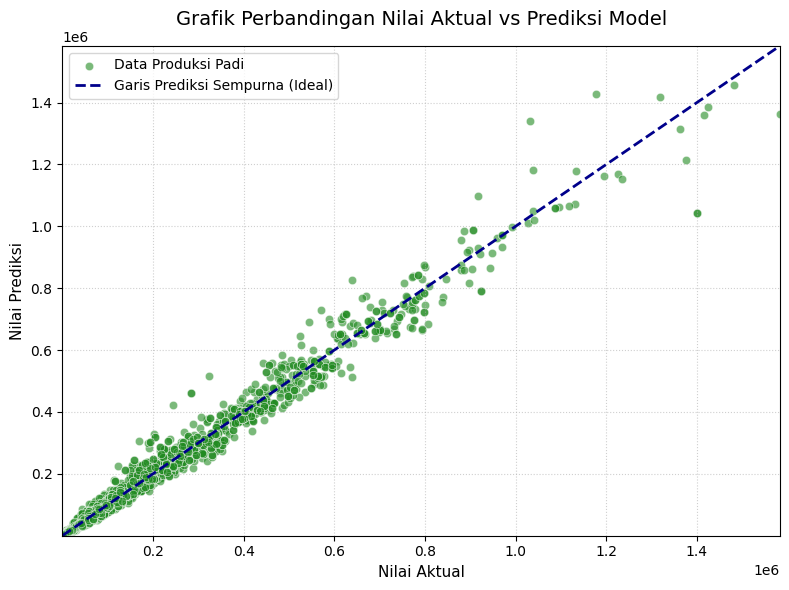

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_aktual_total, 
    y=y_prediksi_total, 
    alpha=0.6, 
    color='forestgreen', 
    edgecolor='w', 
    label='Data Produksi Padi'
)

lims = [
    min(min(y_aktual_total), min(y_prediksi_total)),  # nilai minimum
    max(max(y_aktual_total), max(y_prediksi_total))   # nilai maksimum
]
plt.plot(lims, lims, color='darkblue', linestyle='--', linewidth=2, label='Garis Prediksi Sempurna (Ideal)')

plt.title('Grafik Perbandingan Nilai Aktual vs Prediksi Model', fontsize=14, pad=15)
plt.xlabel('Nilai Aktual', fontsize=11)
plt.ylabel('Nilai Prediksi', fontsize=11)
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE,'random_forest/actual_vs_predicted.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()